In [6]:
# Data Processing
import pandas as pd
import numpy as np

# Text Cleaning
import re
import string

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
# import plotly.express as px
from wordcloud import WordCloud

# Feature Engineering
from sklearn.feature_extraction.text import TfidfVectorizer

# Train Test Split
from sklearn.model_selection import train_test_split

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Model Saving
import pickle

# Streamlit
import streamlit as st

In [7]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [8]:
df = pd.read_csv("D:/Project#5/data/clinical_trials_raw_patient2trial_conditions.csv")
df

,source_condition_query,nct_id,title,official_title,brief_summary,conditions,interventions,overall_status,study_type,phase,sex,minimum_age,maximum_age,healthy_volunteers,eligibility_criteria,clinicaltrials_url
0,breast cancer,NCT03676114,Effect of Perioperative Low Dose Ketamine on P...,Effect of Perioperative Low Dose Ketamine on P...,Breast cancer patients often have perioperativ...,Breast Cancer,ketamine | Normal saline,UNKNOWN,INTERVENTIONAL,PHASE4,FEMALE,20 Years,65 Years,False,Inclusion Criteria:\n\n1. American Society of ...,https://clinicaltrials.gov/study/NCT03676114
1,breast cancer,NCT02941614,Implementing Systematic Distress Screening in ...,Implementing Systematic Distress Screening in ...,Many breast cancer patients experience psychol...,Breast Cancer,Distress screening,COMPLETED,OBSERVATIONAL,NaN,ALL,18 Years,NaN,False,Inclusion Criteria:\n\n* Newly diagnosed with ...,https://clinicaltrials.gov/study/NCT02941614
2,breast cancer,NCT04509063,Investigating Public Enthusiasm for Mammograph...,Investigating Public Enthusiasm for Mammograph...,"Based on an American study by Scherer et al., ...",Breast Neoplasm Female | Mammography Screening...,Information about hypothetical mammography scr...,COMPLETED,INTERVENTIONAL,NaN,FEMALE,44 Years,49 Years,True,Inclusion Criteria:\n\n* Residence: Central De...,https://clinicaltrials.gov/study/NCT04509063
3,breast cancer,NCT04327063,MIRs 04 : Interpectoral Nerve Block With Ropiv...,A Double-blind Randomized Trial of Interpector...,Compare the effect of ropivacaine versus place...,Malignant Neoplasm of Breast,Saline | Ropivacaine,COMPLETED,INTERVENTIONAL,PHASE3,FEMALE,18 Years,85 Years,False,Inclusion Criteria:\n\n1. Women with non-metas...,https://clinicaltrials.gov/study/NCT04327063
4,breast cancer,NCT06778863,A Study of CLSP-1025 in Adult Patients With So...,GUARDIAN-101: A Phase 1 Dose Escalation and Ex...,Phase 1 dose escalation and expansion study of...,Advanced Solid Tumor | Unresectable Solid Tumo...,CLSP-1025,RECRUITING,INTERVENTIONAL,PHASE1,ALL,18 Years,NaN,False,Key Inclusion Criteria:\n\n* Patients must be ...,https://clinicaltrials.gov/study/NCT06778863
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60332,sickle cell anemia,NCT03293641,Zinc Supplementation in Children With Sickle C...,The Effects of Zinc Supplementation in Childre...,Zinc is a nutritionally essential trace elemen...,Sickle Cell Disease | Zinc Deficiency | Infection,Zinc Sulfate Tablets | Standard of Care,COMPLETED,INTERVENTIONAL,NaN,ALL,6 Months,12 Years,False,Inclusion Criteria:\n\n* Male or female infant...,https://clinicaltrials.gov/study/NCT03293641
60333,sickle cell anemia,NCT02197845,Enhancing Use of Hydroxyurea In Sickle Cell Di...,Enhancing Use of Hydroxyurea In Sickle Cell Di...,"Multi-phase, patient navigator-based program i...",Sickle Cell Disease,Patient Navigator | Recruitment into Specialty...,COMPLETED,INTERVENTIONAL,NaN,ALL,15 Years,NaN,False,PHASE I:\n\nInclusion Criteria:\n\n* Patient S...,https://clinicaltrials.gov/study/NCT02197845
60334,sickle cell anemia,NCT01718054,Vascular Function Intervention Trial in Sickle...,Development of a Ready-to-use Nutraceutical Fo...,Sickle cell disease (SCD) is the most common i...,Sickle Cell Disease,Vascular ready-to-use supplementary food | Reg...,UNKNOWN,INTERVENTIONAL,PHASE2 | PHASE3,ALL,8 Years,11 Years,False,Inclusion Criteria:\n\n* Aged 8-11 years old a...,https://clinicaltrials.gov/study/NCT01718054
60335,sickle cell anemia,NCT06647979,Hematopoietic Stem Cell BCL11A Enhancer Gene E...,An Adaptive Design Basket Trial of Hematopoiet...,A promising approach for the treatment of gene...,Sickle Cell Disease | Sickle Cell Anemia (HbSS...,autologous bone marrow derived CD34+ HSPCs ele...,RECRUITING,INTERVENTIONAL,PHASE1,ALL,13 Years,40 Years,False,Inclusion Criteria:\n\n1. Diagnosis of either ...,https://clinicaltrials.gov/study/NCT06647979


In [9]:
print(df.shape)

(60337, 16)


In [10]:
df.head()

,source_condition_query,nct_id,title,official_title,brief_summary,conditions,interventions,overall_status,study_type,phase,sex,minimum_age,maximum_age,healthy_volunteers,eligibility_criteria,clinicaltrials_url
0,breast cancer,NCT03676114,Effect of Perioperative Low Dose Ketamine on P...,Effect of Perioperative Low Dose Ketamine on P...,Breast cancer patients often have perioperativ...,Breast Cancer,ketamine | Normal saline,UNKNOWN,INTERVENTIONAL,PHASE4,FEMALE,20 Years,65 Years,False,Inclusion Criteria:\n\n1. American Society of ...,https://clinicaltrials.gov/study/NCT03676114
1,breast cancer,NCT02941614,Implementing Systematic Distress Screening in ...,Implementing Systematic Distress Screening in ...,Many breast cancer patients experience psychol...,Breast Cancer,Distress screening,COMPLETED,OBSERVATIONAL,NaN,ALL,18 Years,NaN,False,Inclusion Criteria:\n\n* Newly diagnosed with ...,https://clinicaltrials.gov/study/NCT02941614
2,breast cancer,NCT04509063,Investigating Public Enthusiasm for Mammograph...,Investigating Public Enthusiasm for Mammograph...,"Based on an American study by Scherer et al., ...",Breast Neoplasm Female | Mammography Screening...,Information about hypothetical mammography scr...,COMPLETED,INTERVENTIONAL,NaN,FEMALE,44 Years,49 Years,True,Inclusion Criteria:\n\n* Residence: Central De...,https://clinicaltrials.gov/study/NCT04509063
3,breast cancer,NCT04327063,MIRs 04 : Interpectoral Nerve Block With Ropiv...,A Double-blind Randomized Trial of Interpector...,Compare the effect of ropivacaine versus place...,Malignant Neoplasm of Breast,Saline | Ropivacaine,COMPLETED,INTERVENTIONAL,PHASE3,FEMALE,18 Years,85 Years,False,Inclusion Criteria:\n\n1. Women with non-metas...,https://clinicaltrials.gov/study/NCT04327063
4,breast cancer,NCT06778863,A Study of CLSP-1025 in Adult Patients With So...,GUARDIAN-101: A Phase 1 Dose Escalation and Ex...,Phase 1 dose escalation and expansion study of...,Advanced Solid Tumor | Unresectable Solid Tumo...,CLSP-1025,RECRUITING,INTERVENTIONAL,PHASE1,ALL,18 Years,NaN,False,Key Inclusion Criteria:\n\n* Patients must be ...,https://clinicaltrials.gov/study/NCT06778863


In [11]:
df.columns

Index(['source_condition_query', 'nct_id', 'title', 'official_title',
       'brief_summary', 'conditions', 'interventions', 'overall_status',
       'study_type', 'phase', 'sex', 'minimum_age', 'maximum_age',
       'healthy_volunteers', 'eligibility_criteria', 'clinicaltrials_url'],
      dtype='str')

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 60337 entries, 0 to 60336
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   source_condition_query  60337 non-null  str   
 1   nct_id                  60337 non-null  str   
 2   title                   60337 non-null  str   
 3   official_title          59551 non-null  str   
 4   brief_summary           60337 non-null  str   
 5   conditions              60336 non-null  str   
 6   interventions           54276 non-null  str   
 7   overall_status          60337 non-null  str   
 8   study_type              60337 non-null  str   
 9   phase                   23336 non-null  str   
 10  sex                     60304 non-null  str   
 11  minimum_age             57121 non-null  str   
 12  maximum_age             28400 non-null  str   
 13  healthy_volunteers      58857 non-null  object
 14  eligibility_criteria    60326 non-null  str   
 15  clinicaltrial

In [13]:
df.isnull().sum()

source_condition_query        0
nct_id                        0
title                         0
official_title              786
brief_summary                 0
conditions                    1
interventions              6061
overall_status                0
study_type                    0
phase                     37001
sex                          33
minimum_age                3216
maximum_age               31937
healthy_volunteers         1480
eligibility_criteria         11
clinicaltrials_url            0
dtype: int64

In [14]:
df.columns

Index(['source_condition_query', 'nct_id', 'title', 'official_title',
       'brief_summary', 'conditions', 'interventions', 'overall_status',
       'study_type', 'phase', 'sex', 'minimum_age', 'maximum_age',
       'healthy_volunteers', 'eligibility_criteria', 'clinicaltrials_url'],
      dtype='str')

In [15]:
nlp_df = df[['brief_summary']]


In [16]:
nlp_df.head()

,brief_summary
0,Breast cancer patients often have perioperativ...
1,Many breast cancer patients experience psychol...
2,"Based on an American study by Scherer et al., ..."
3,Compare the effect of ropivacaine versus place...
4,Phase 1 dose escalation and expansion study of...


In [17]:
nlp_df['brief_summary'].isnull().sum()

np.int64(0)

In [18]:
df['source_condition_query']

0             breast cancer
1             breast cancer
2             breast cancer
3             breast cancer
4             breast cancer
                ...        
60332    sickle cell anemia
60333    sickle cell anemia
60334    sickle cell anemia
60335    sickle cell anemia
60336    sickle cell anemia
Name: source_condition_query, Length: 60337, dtype: str

In [19]:
df['source_condition_query'].nunique()

8

In [20]:
df['source_condition_query'].value_counts().head(20)

source_condition_query
breast cancer                            16301
type 2 diabetes                          11467
covid-19                                 10153
anxiety                                   9286
chronic obstructive pulmonary disease     6181
rheumatoid arthritis                      3637
glaucoma                                  2173
sickle cell anemia                        1139
Name: count, dtype: int64

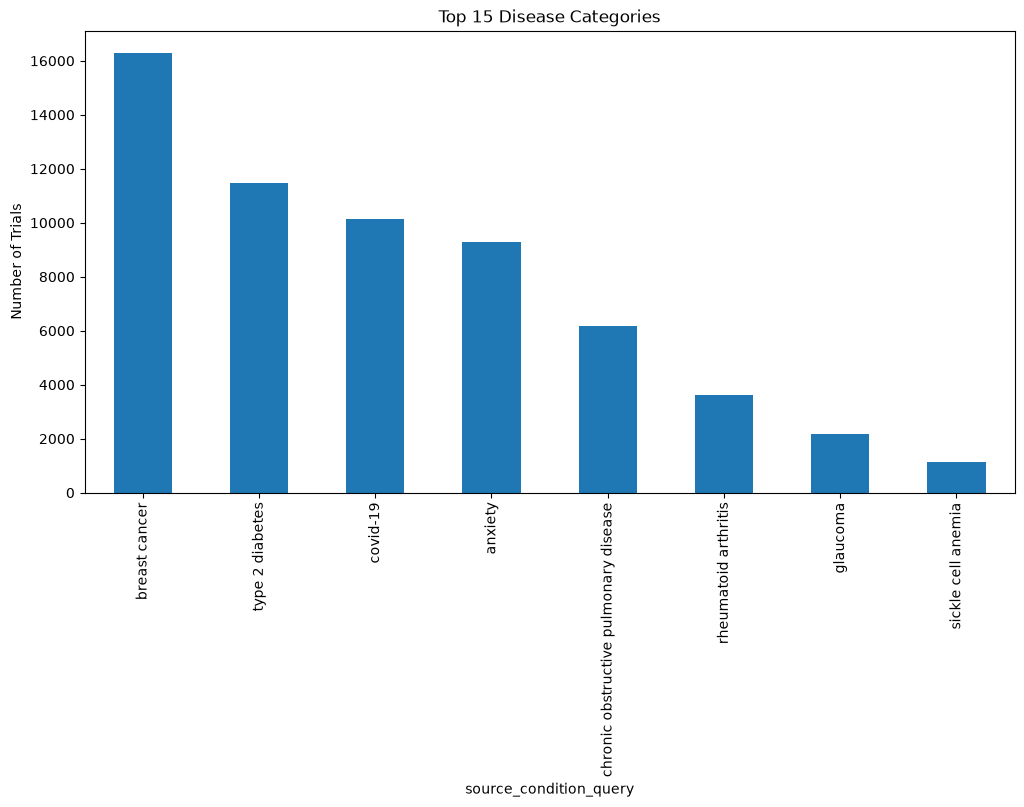

In [21]:
top_disease = df['source_condition_query'].value_counts().head(15)

plt.figure(figsize=(12,6))

top_disease.plot(kind='bar')

plt.title("Top 15 Disease Categories")
plt.ylabel("Number of Trials")
plt.show()

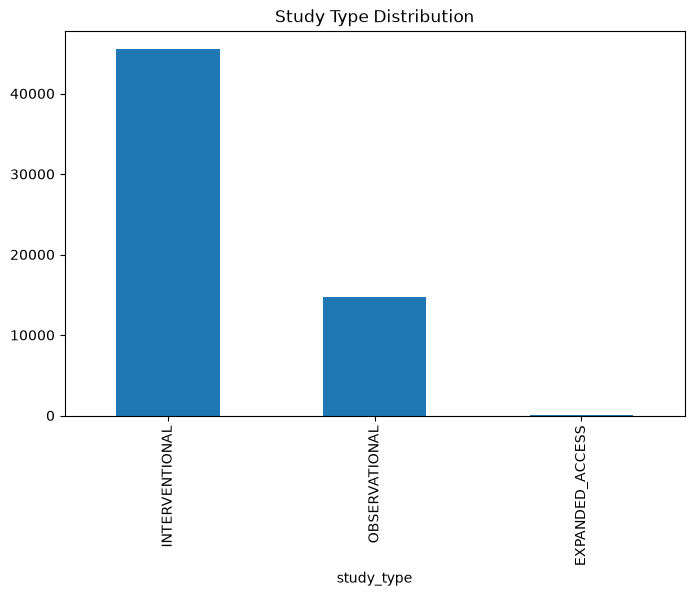

In [22]:
df['study_type'].value_counts().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Study Type Distribution")
plt.show()

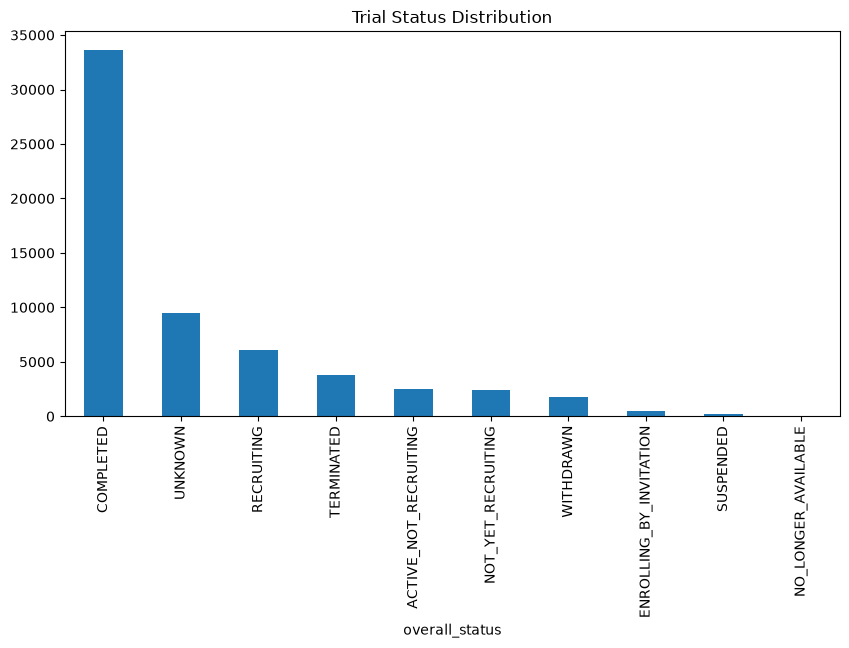

In [23]:
df['overall_status'].value_counts().head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Trial Status Distribution")
plt.show()

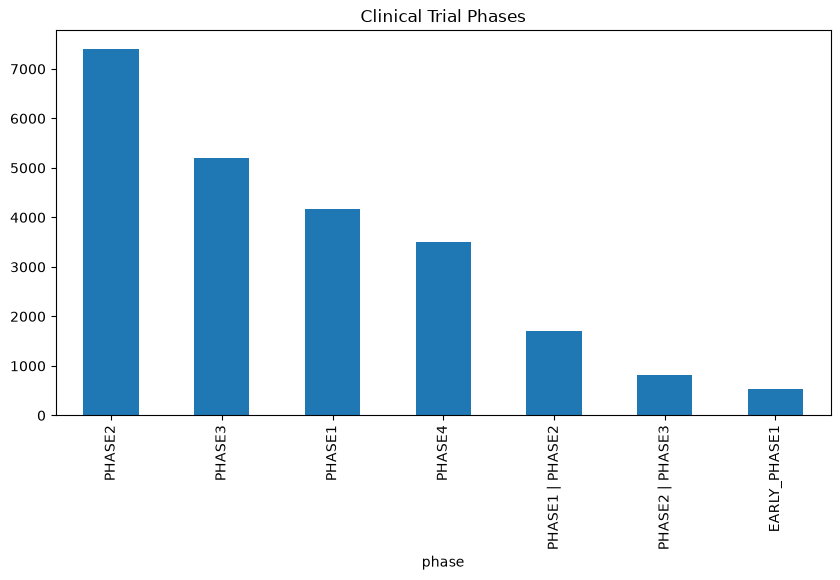

In [24]:
df['phase'].value_counts().plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Clinical Trial Phases")
plt.show()

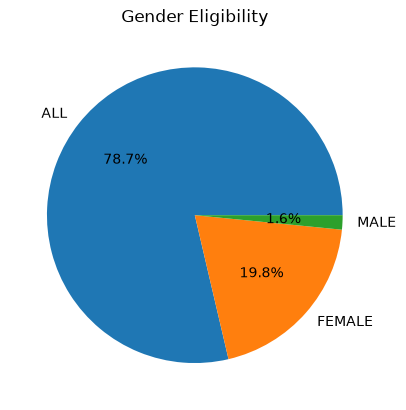

In [25]:
df['sex'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel("")
plt.title("Gender Eligibility")
plt.show()

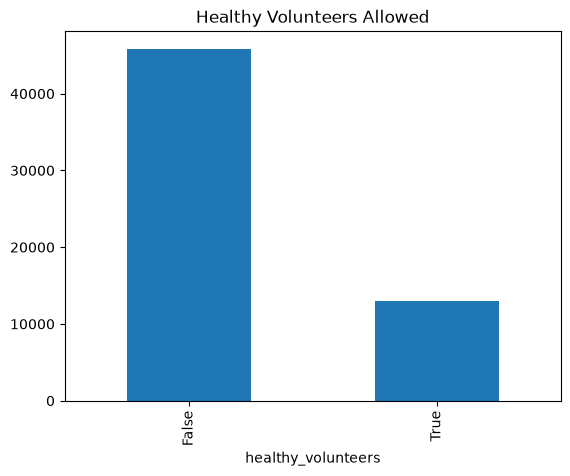

In [26]:
df['healthy_volunteers'].value_counts().plot(
    kind='bar'
)

plt.title("Healthy Volunteers Allowed")
plt.show()

In [27]:
df[['minimum_age','maximum_age']].head()

,minimum_age,maximum_age
0,20 Years,65 Years
1,18 Years,NaN
2,44 Years,49 Years
3,18 Years,85 Years
4,18 Years,NaN


In [28]:
df['summary_length'] = (
    df['brief_summary']
    .astype(str)
    .apply(len)
)

In [29]:
df['summary_length'].describe()

count    60337.000000
mean       688.297396
std        630.584628
min         17.000000
25%        253.000000
50%        466.000000
75%        904.000000
max       5011.000000
Name: summary_length, dtype: float64

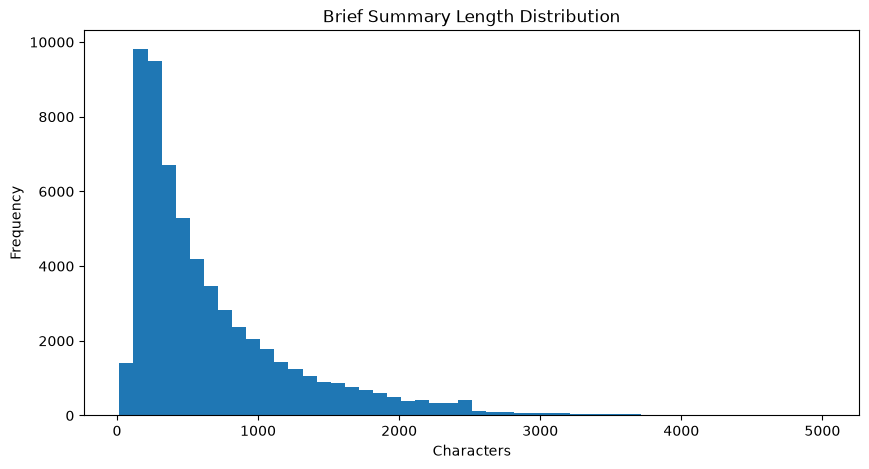

In [30]:
plt.figure(figsize=(10,5))

plt.hist(
    df['summary_length'],
    bins=50
)

plt.title("Brief Summary Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Frequency")

plt.show()

In [31]:
disease_counts = (
    df['source_condition_query']
    .value_counts()
)

In [32]:
disease_counts.head(20)

source_condition_query
breast cancer                            16301
type 2 diabetes                          11467
covid-19                                 10153
anxiety                                   9286
chronic obstructive pulmonary disease     6181
rheumatoid arthritis                      3637
glaucoma                                  2173
sickle cell anemia                        1139
Name: count, dtype: int64

In [33]:
# Text Columns
df['official_title'] = df['official_title'].fillna('Not Available')
df['conditions'] = df['conditions'].fillna('Not Available')
df['interventions'] = df['interventions'].fillna('Not Available')
df['eligibility_criteria'] = df['eligibility_criteria'].fillna('Not Available')

# Categorical Columns
df['sex'] = df['sex'].fillna('Unknown')
df['healthy_volunteers'] = df['healthy_volunteers'].fillna('Unknown')

# Age Columns
df['minimum_age'] = df['minimum_age'].fillna('Not Specified')
df['maximum_age'] = df['maximum_age'].fillna('Not Specified')

# Phase Column
df['phase'] = df['phase'].fillna('Not Applicable')

In [34]:
df.isnull().sum()

source_condition_query    0
nct_id                    0
title                     0
official_title            0
brief_summary             0
conditions                0
interventions             0
overall_status            0
study_type                0
phase                     0
sex                       0
minimum_age               0
maximum_age               0
healthy_volunteers        0
eligibility_criteria      0
clinicaltrials_url        0
summary_length            0
dtype: int64

In [35]:
# Number of duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

print("Shape After Removing Duplicates:", df.shape)

Duplicate Rows: 0
Shape After Removing Duplicates: (60337, 17)


In [36]:
columns_to_drop = [
    'nct_id',
    'sex',
    'Clinical Trial Phases',
    'minimum_age',
    'phase',
    'maximum_age'
]

df = df.drop(columns=columns_to_drop, errors='ignore')

In [37]:
df

,source_condition_query,title,official_title,brief_summary,conditions,interventions,overall_status,study_type,healthy_volunteers,eligibility_criteria,clinicaltrials_url,summary_length
0,breast cancer,Effect of Perioperative Low Dose Ketamine on P...,Effect of Perioperative Low Dose Ketamine on P...,Breast cancer patients often have perioperativ...,Breast Cancer,ketamine | Normal saline,UNKNOWN,INTERVENTIONAL,False,Inclusion Criteria:\n\n1. American Society of ...,https://clinicaltrials.gov/study/NCT03676114,499
1,breast cancer,Implementing Systematic Distress Screening in ...,Implementing Systematic Distress Screening in ...,Many breast cancer patients experience psychol...,Breast Cancer,Distress screening,COMPLETED,OBSERVATIONAL,False,Inclusion Criteria:\n\n* Newly diagnosed with ...,https://clinicaltrials.gov/study/NCT02941614,2113
2,breast cancer,Investigating Public Enthusiasm for Mammograph...,Investigating Public Enthusiasm for Mammograph...,"Based on an American study by Scherer et al., ...",Breast Neoplasm Female | Mammography Screening...,Information about hypothetical mammography scr...,COMPLETED,INTERVENTIONAL,True,Inclusion Criteria:\n\n* Residence: Central De...,https://clinicaltrials.gov/study/NCT04509063,338
3,breast cancer,MIRs 04 : Interpectoral Nerve Block With Ropiv...,A Double-blind Randomized Trial of Interpector...,Compare the effect of ropivacaine versus place...,Malignant Neoplasm of Breast,Saline | Ropivacaine,COMPLETED,INTERVENTIONAL,False,Inclusion Criteria:\n\n1. Women with non-metas...,https://clinicaltrials.gov/study/NCT04327063,172
4,breast cancer,A Study of CLSP-1025 in Adult Patients With So...,GUARDIAN-101: A Phase 1 Dose Escalation and Ex...,Phase 1 dose escalation and expansion study of...,Advanced Solid Tumor | Unresectable Solid Tumo...,CLSP-1025,RECRUITING,INTERVENTIONAL,False,Key Inclusion Criteria:\n\n* Patients must be ...,https://clinicaltrials.gov/study/NCT06778863,176
...,...,...,...,...,...,...,...,...,...,...,...,...
60332,sickle cell anemia,Zinc Supplementation in Children With Sickle C...,The Effects of Zinc Supplementation in Childre...,Zinc is a nutritionally essential trace elemen...,Sickle Cell Disease | Zinc Deficiency | Infection,Zinc Sulfate Tablets | Standard of Care,COMPLETED,INTERVENTIONAL,False,Inclusion Criteria:\n\n* Male or female infant...,https://clinicaltrials.gov/study/NCT03293641,778
60333,sickle cell anemia,Enhancing Use of Hydroxyurea In Sickle Cell Di...,Enhancing Use of Hydroxyurea In Sickle Cell Di...,"Multi-phase, patient navigator-based program i...",Sickle Cell Disease,Patient Navigator | Recruitment into Specialty...,COMPLETED,INTERVENTIONAL,False,PHASE I:\n\nInclusion Criteria:\n\n* Patient S...,https://clinicaltrials.gov/study/NCT02197845,501
60334,sickle cell anemia,Vascular Function Intervention Trial in Sickle...,Development of a Ready-to-use Nutraceutical Fo...,Sickle cell disease (SCD) is the most common i...,Sickle Cell Disease,Vascular ready-to-use supplementary food | Reg...,UNKNOWN,INTERVENTIONAL,False,Inclusion Criteria:\n\n* Aged 8-11 years old a...,https://clinicaltrials.gov/study/NCT01718054,1490
60335,sickle cell anemia,Hematopoietic Stem Cell BCL11A Enhancer Gene E...,An Adaptive Design Basket Trial of Hematopoiet...,A promising approach for the treatment of gene...,Sickle Cell Disease | Sickle Cell Anemia (HbSS...,autologous bone marrow derived CD34+ HSPCs ele...,RECRUITING,INTERVENTIONAL,False,Inclusion Criteria:\n\n1. Diagnosis of either ...,https://clinicaltrials.gov/study/NCT06647979,1625


In [38]:
columns_to_drop = [
    'clinicaltrials_url',
    'summary_length'
]

df = df.drop(columns=columns_to_drop, errors='ignore')

print("Updated Shape:", df.shape)
print(df.columns.tolist())

Updated Shape: (60337, 10)
['source_condition_query', 'title', 'official_title', 'brief_summary', 'conditions', 'interventions', 'overall_status', 'study_type', 'healthy_volunteers', 'eligibility_criteria']


In [39]:
def clean_text(text):
    # Convert to string
    text = str(text)

    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [40]:
df.drop(columns=['cleaned_text'], inplace=True)

KeyError: "['cleaned_text'] not found in axis"

In [41]:
df['brief_summaries'] = df['brief_summary'].apply(clean_text)
df = df.drop(columns=['brief_summary'])

print(df.columns.tolist())

['source_condition_query', 'title', 'official_title', 'conditions', 'interventions', 'overall_status', 'study_type', 'healthy_volunteers', 'eligibility_criteria', 'brief_summaries']


In [49]:
for i in range(3):
    print("Original:")
    print(df['brief_summary'].iloc[i])

    print("\nCleaned:")
    print(df['cleaned_text'].iloc[i])

    print("-" * 100)

Original:


KeyError: 'brief_summary'

In [ ]:
df.isnull().sum()

source_condition_query    0
title                     0
official_title            0
conditions                0
interventions             0
overall_status            0
study_type                0
healthy_volunteers        0
eligibility_criteria      0
brief_summaries           0
dtype: int64

In [42]:
df

,source_condition_query,title,official_title,conditions,interventions,overall_status,study_type,healthy_volunteers,eligibility_criteria,brief_summaries
0,breast cancer,Effect of Perioperative Low Dose Ketamine on P...,Effect of Perioperative Low Dose Ketamine on P...,Breast Cancer,ketamine | Normal saline,UNKNOWN,INTERVENTIONAL,False,Inclusion Criteria:\n\n1. American Society of ...,breast cancer patients often have perioperativ...
1,breast cancer,Implementing Systematic Distress Screening in ...,Implementing Systematic Distress Screening in ...,Breast Cancer,Distress screening,COMPLETED,OBSERVATIONAL,False,Inclusion Criteria:\n\n* Newly diagnosed with ...,many breast cancer patients experience psychol...
2,breast cancer,Investigating Public Enthusiasm for Mammograph...,Investigating Public Enthusiasm for Mammograph...,Breast Neoplasm Female | Mammography Screening...,Information about hypothetical mammography scr...,COMPLETED,INTERVENTIONAL,True,Inclusion Criteria:\n\n* Residence: Central De...,based on an american study by scherer et al it...
3,breast cancer,MIRs 04 : Interpectoral Nerve Block With Ropiv...,A Double-blind Randomized Trial of Interpector...,Malignant Neoplasm of Breast,Saline | Ropivacaine,COMPLETED,INTERVENTIONAL,False,Inclusion Criteria:\n\n1. Women with non-metas...,compare the effect of ropivacaine versus place...
4,breast cancer,A Study of CLSP-1025 in Adult Patients With So...,GUARDIAN-101: A Phase 1 Dose Escalation and Ex...,Advanced Solid Tumor | Unresectable Solid Tumo...,CLSP-1025,RECRUITING,INTERVENTIONAL,False,Key Inclusion Criteria:\n\n* Patients must be ...,phase dose escalation and expansion study of c...
...,...,...,...,...,...,...,...,...,...,...
60332,sickle cell anemia,Zinc Supplementation in Children With Sickle C...,The Effects of Zinc Supplementation in Childre...,Sickle Cell Disease | Zinc Deficiency | Infection,Zinc Sulfate Tablets | Standard of Care,COMPLETED,INTERVENTIONAL,False,Inclusion Criteria:\n\n* Male or female infant...,zinc is a nutritionally essential trace elemen...
60333,sickle cell anemia,Enhancing Use of Hydroxyurea In Sickle Cell Di...,Enhancing Use of Hydroxyurea In Sickle Cell Di...,Sickle Cell Disease,Patient Navigator | Recruitment into Specialty...,COMPLETED,INTERVENTIONAL,False,PHASE I:\n\nInclusion Criteria:\n\n* Patient S...,multiphase patient navigatorbased program in t...
60334,sickle cell anemia,Vascular Function Intervention Trial in Sickle...,Development of a Ready-to-use Nutraceutical Fo...,Sickle Cell Disease,Vascular ready-to-use supplementary food | Reg...,UNKNOWN,INTERVENTIONAL,False,Inclusion Criteria:\n\n* Aged 8-11 years old a...,sickle cell disease scd is the most common inh...
60335,sickle cell anemia,Hematopoietic Stem Cell BCL11A Enhancer Gene E...,An Adaptive Design Basket Trial of Hematopoiet...,Sickle Cell Disease | Sickle Cell Anemia (HbSS...,autologous bone marrow derived CD34+ HSPCs ele...,RECRUITING,INTERVENTIONAL,False,Inclusion Criteria:\n\n1. Diagnosis of either ...,a promising approach for the treatment of gene...


In [50]:
stop_words = set(stopwords.words('english'))

In [51]:
text_columns = [
    'source_condition_query',
    'title',
    'official_title',
    'conditions',
    'interventions',
    'overall_status',
    'study_type',
    'healthy_volunteers',
    'eligibility_criteria',
    'brief_summaries'
]

In [52]:
import re
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    
    if pd.isna(text):
        return ""
    
    text = str(text).lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    
    # Remove special characters, punctuation, numbers
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Remove stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words]
    
    return " ".join(words)

In [53]:
for col in text_columns:
    if col in df.columns:
        df[col] = df[col].apply(preprocess_text)

In [54]:
feature_columns = [
    'official_title',
    'interventions',
    'study_type',
    'healthy_volunteers',
    'eligibility_criteria',
    'brief_summaries'
]

df['cleaned_columns'] = (
    df[feature_columns]
    .fillna('')
    .astype(str)
    .agg(' '.join, axis=1)
)

In [55]:
df['cleaned_columns'] = df['cleaned_columns'].apply(preprocess_text)

In [56]:
X = df['cleaned_columns']
y = df['source_condition_query']

In [57]:
model_df = df[['cleaned_columns', 'source_condition_query']].copy()

print(model_df.shape)
model_df.head()

(60337, 2)


,cleaned_columns,source_condition_query
0,effect perioperative low dose ketamine postope...,breast cancer
1,implementing systematic distress screening bre...,breast cancer
2,investigating public enthusiasm mammography sc...,breast cancer
3,double blind randomized trial interpectoral ne...,breast cancer
4,guardian phase dose escalation expansion study...,breast cancer


In [58]:
from sklearn.preprocessing import LabelEncoder

# Encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X_tfidf = tfidf.fit_transform(X)

KeyboardInterrupt: 

In [ ]:
import nltk

nltk.download('punkt_tab')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [59]:
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

In [60]:
def tokenize_lemmatize(text):

    # Tokenization
    tokens = word_tokenize(str(text))

    # Lemmatization + remove stopwords + keep alphabetic words
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word.isalpha() and word not in stop_words
    ]

    return " ".join(tokens)

In [63]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def fast_lemmatize(text):
    words = str(text).split()

    return " ".join(
        lemmatizer.lemmatize(word)
        for word in words
    )

In [64]:
df['lemmatized_text'] = df['cleaned_columns'].apply(tokenize_lemmatize)

In [65]:
df[['cleaned_columns', 'lemmatized_text']].head()

,cleaned_columns,lemmatized_text
0,effect perioperative low dose ketamine postope...,effect perioperative low dose ketamine postope...
1,implementing systematic distress screening bre...,implementing systematic distress screening bre...
2,investigating public enthusiasm mammography sc...,investigating public enthusiasm mammography sc...
3,double blind randomized trial interpectoral ne...,double blind randomized trial interpectoral ne...
4,guardian phase dose escalation expansion study...,guardian phase dose escalation expansion study...


In [66]:
#checking for empty rows
print("Empty rows:", (df['lemmatized_text'].str.strip() == '').sum())

Empty rows: 0


Moving to TF-IDF

In [67]:
X = df['lemmatized_text']
y = df['source_condition_query']

In [68]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2
)

X_tfidf = tfidf.fit_transform(X)

In [69]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df['target_encoded'] = label_encoder.fit_transform(df['source_condition_query'])

In [70]:
y = df['target_encoded']

In [71]:
label_mapping = dict(
    zip(label_encoder.classes_,
        range(len(label_encoder.classes_)))
)

print(label_mapping)

{'anxiety': 0, 'breast cancer': 1, 'chronic obstructive pulmonary disease': 2, 'covid': 3, 'glaucoma': 4, 'rheumatoid arthritis': 5, 'sickle cell anemia': 6, 'type diabetes': 7}


In [72]:
import joblib

joblib.dump(label_encoder, 'label_encoder.pkl')

['label_encoder.pkl']

In [73]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [74]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](8,)","[ 7429.,13041., 4945.,..., 2910., 911., 9173.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](8,)","[-1.87,-1.31,-2.28,...,-2.81,-3.97,-1.66]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](8,)","[0,1,2,...,5,6,7]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](8, 10000)","[[ 1.07, 0. , 1.9 ,..., 0. , 0. , 0.14], [ 4.72, 0.03,13.21,...,13.26,13.23, 2.07], [ 2.11, 0.34, 0.67,..., 0. , 0. , 0.76], ..., [ 3.25,35.74, 0.09,..., 0.87, 0.87, 9.97], [ 0.85, 0.5 , 0. ,..., 0.52, 0.52, 0.12], [ 3.27, 0. , 0.39,..., 0.07, 0.07, 0.34]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](8, 10000)","[[-10.5 ,-11.23,-10.16,...,-11.23,-11.23,-11.09], [-10.26,-11.98, -9.35,..., -9.35, -9.35,-10.89], [ -9.89,-10.73,-10.51,...,-11.02,-11.02,-10.46], ..., [ -9.15, -7. ,-10.52,..., -9.98, -9.97, -8.21], [ -9.25, -9.46, -9.87,..., -9.45, -9.45, -9.75], [-10.13,-11.58,-11.25,...,-11.51,-11.51,-11.29]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10000


In [75]:
predicted_class = nb_model.predict(X_test)

original_label = label_encoder.inverse_transform(predicted_class)

print(original_label[:10])

['anxiety' 'breast cancer' 'chronic obstructive pulmonary disease'
 'breast cancer' 'anxiety' 'breast cancer'
 'chronic obstructive pulmonary disease' 'anxiety' 'rheumatoid arthritis'
 'breast cancer']


In [76]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

predicted_class = nb_model.predict(X_test)

In [77]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, predicted_class)

print("Accuracy:", accuracy)

print(classification_report(y_test, predicted_class))

Accuracy: 0.9175505469008949
              precision    recall  f1-score   support

           0       0.76      0.96      0.85      1857
           1       0.98      0.92      0.95      3260
           2       0.96      0.82      0.88      1236
           3       0.94      0.90      0.92      2031
           4       0.95      0.96      0.96       435
           5       0.97      0.90      0.94       727
           6       0.98      0.86      0.92       228
           7       0.93      0.95      0.94      2294

    accuracy                           0.92     12068
   macro avg       0.93      0.91      0.92     12068
weighted avg       0.93      0.92      0.92     12068



In [78]:
original_label = label_encoder.inverse_transform(predicted_class)

In [79]:
print(globals().keys())

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__vsc_ipynb_file__', '_i', '_ii', '_iii', '_i1', '_i2', '_i3', 'pd', 'np', 're', 'string', 'nltk', 'stopwords', 'word_tokenize', 'WordNetLemmatizer', 'plt', 'sns', 'WordCloud', 'TfidfVectorizer', 'train_test_split', 'LogisticRegression', 'MultinomialNB', 'RandomForestClassifier', 'LinearSVC', 'accuracy_score', 'precision_score', 'recall_score', 'f1_score', 'classification_report', 'confusion_matrix', 'pickle', 'st', '_i4', '_4', '_i5', '_i6', '_i7', '_7', '_i8', 'df', '_8', '_i9', '_i10', '_10', '_i11', '_11', '_i12', '_i13', '_13', '_i14', '_14', '_i15', 'nlp_df', '_i16', '_16', '_i17', '_17', '_i18', '_18', '_i19', '_19', '_i20', '_20', '_i21', 'top_disease', '_i22', '_i23', '_i24', '_i25', '_i26', '_i27', '_27', '_i28', '_i29', '_29', '_i30', '_i31', 'disease_counts', '_i32', '_32', '_i33

In [80]:
X_tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 11147141 stored elements and shape (60337, 10000)>

In [81]:
y_pred = nb_model.predict(X_test)

In [82]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.9175505469008949
              precision    recall  f1-score   support

           0       0.76      0.96      0.85      1857
           1       0.98      0.92      0.95      3260
           2       0.96      0.82      0.88      1236
           3       0.94      0.90      0.92      2031
           4       0.95      0.96      0.96       435
           5       0.97      0.90      0.94       727
           6       0.98      0.86      0.92       228
           7       0.93      0.95      0.94      2294

    accuracy                           0.92     12068
   macro avg       0.93      0.91      0.92     12068
weighted avg       0.93      0.92      0.92     12068



In [84]:
predicted_labels = label_encoder.inverse_transform(y_pred)

print(predicted_labels[:10])

['anxiety' 'breast cancer' 'chronic obstructive pulmonary disease'
 'breast cancer' 'anxiety' 'breast cancer'
 'chronic obstructive pulmonary disease' 'anxiety' 'rheumatoid arthritis'
 'breast cancer']


In [96]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    # n_jobs=-1
)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.971163407358303


In [97]:
print("Naive Bayes:",
      accuracy_score(y_test, y_pred))

print("Logistic Regression:",
      accuracy_score(y_test, lr_pred))

Naive Bayes: 0.9175505469008949
Logistic Regression: 0.971163407358303


In [98]:
df[['source_condition_query', 'official_title']].sample(10)

,source_condition_query,official_title
33247,rheumatoid arthritis,multi national multi center non interventional...
30199,chronic obstructive pulmonary disease,phase open label dose escalation multicentre s...
26032,covid,project sepsis blood markers including molecul...
17879,covid,washed microbiota transplantation patients nco...
53741,anxiety,understanding well physical therapy students m...
14920,breast cancer,double blind placebo controlled randomized pha...
52240,anxiety,effect mobilization protocol developed knee ar...
47469,type diabetes,phase randomised investigator participant blin...
42808,type diabetes,phase iii randomised double blind placebo cont...
16122,breast cancer,prospective non interventional study evaluate ...


In [90]:
print("Number of classes:", df['source_condition_query'].nunique())

print(df['source_condition_query'].value_counts().head(20))

Number of classes: 8
source_condition_query
breast cancer                            16301
type diabetes                            11467
covid                                    10153
anxiety                                   9286
chronic obstructive pulmonary disease     6181
rheumatoid arthritis                      3637
glaucoma                                  2173
sickle cell anemia                        1139
Name: count, dtype: int64


In [91]:
import joblib

# Save model
joblib.dump(lr_model, "clinical_trial_lr_model.pkl")

# Save TF-IDF vectorizer
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

# Save label encoder
joblib.dump(label_encoder, "label_encoder.pkl")

print("All files saved successfully!")

All files saved successfully!


In [92]:
df.to_csv("clinial_trial_disease_prediction_preprocessed_dataset.csv")


In [99]:
import nltk

nltk.download("stopwords")
nltk.download("wordnet")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True